# 1D Dirac Solver Example

This notebook demonstrates how to use the `dirac_solver` library to set up and run a simple 1D simulation of a free particle.

In [35]:
import sys
sys.path.append('..')
import numpy as np
from dirac_solver.geometry import Grid
from dirac_solver.initial_state import GaussianPacket, ConstantSpinor
from dirac_solver.core import DiracProblemBuilder, DiracSolver
from dirac_solver import _core

## 1. Set up the Simulation Parameters

First, we define the spatial grid for our 1D simulation.

In [36]:
shape = (400,)
spacing = (0.1)
grid = Grid(shape, spacing)

Next, we define the initial state of the particle as a Gaussian wavepacket.

In [37]:
constant_spinor = ConstantSpinor(momentum=[5, 0, 0])
initial_state = GaussianPacket(constant_spinor, center=[0, 0, 0], spatial_width=1.0)

We'll simulate a free particle, so we use the `FreeParticle` potential from the C++ core. We also set periodic boundary conditions.

In [38]:
potential = _core.FreeParticle()
boundary_condition = _core.PeriodicBoundary()

## 2. Build and Run the Simulation

We use the `DiracProblemBuilder` to assemble all the simulation parameters into a `SimulationProblem` object.

In [39]:
problem = DiracProblemBuilder() \
    .set_grid(grid) \
    .set_initial_state(initial_state) \
    .set_potential(potential) \
    .set_boundary_condition(boundary_condition) \
    .set_time_parameters(time_step=0.001, total_time=2.0) \
    .build()

Now, we can create a `DiracSolver` instance and run the simulation.

In [40]:
solver = DiracSolver(problem)

DiracSolver initialized with C++ 'FDTDLeapfrogIntegrator' engine.


In [41]:
solver.run_simulation()

Running simulation for 2000 steps...
  Step 10/2000 complete.
  Step 20/2000 complete.
  Step 30/2000 complete.
  Step 40/2000 complete.
  Step 50/2000 complete.
  Step 60/2000 complete.
  Step 70/2000 complete.
  Step 80/2000 complete.
  Step 90/2000 complete.
  Step 100/2000 complete.
  Step 110/2000 complete.
  Step 120/2000 complete.
  Step 130/2000 complete.
  Step 140/2000 complete.
  Step 150/2000 complete.
  Step 160/2000 complete.
  Step 170/2000 complete.
  Step 180/2000 complete.
  Step 190/2000 complete.
  Step 200/2000 complete.
  Step 210/2000 complete.
  Step 220/2000 complete.
  Step 230/2000 complete.
  Step 240/2000 complete.
  Step 250/2000 complete.
  Step 260/2000 complete.
  Step 270/2000 complete.
  Step 280/2000 complete.
  Step 290/2000 complete.
  Step 300/2000 complete.
  Step 310/2000 complete.
  Step 320/2000 complete.
  Step 330/2000 complete.
  Step 340/2000 complete.
  Step 350/2000 complete.
  Step 360/2000 complete.
  Step 370/2000 complete.
  Step 380

## 3. Visualize the Results

Finally, we can plot the probability density of the spinor field at the end of the simulation.

Plotting probability density...


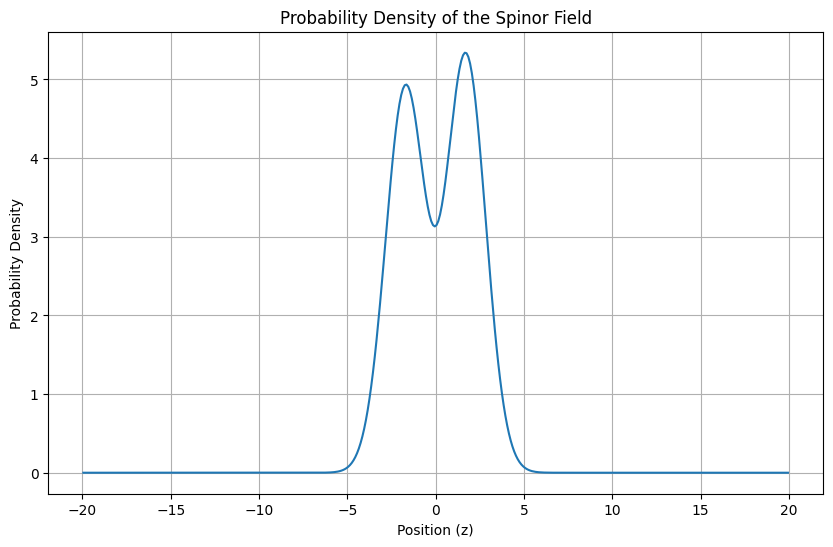

In [42]:
solver.plot_probability_density()